#### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

INPUT_FILE  = "../data/processed/preprocessed.csv"
OUTPUT_FILE = "../data/processed/selected_features.csv"

VARIANCE_THRESHOLD   = 0.01
CORRELATION_THRESHOLD = 0.85
MI_THRESHOLD          = 0.15
N_CLUSTERS            = 5

#### 2. Daten laden

In [2]:
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}, NaN gesamt: {df.isna().sum().sum()}")

Shape: (1142, 60), NaN gesamt: 0


#### 3. Varianz-Filter

Schwellenwert: 0.01
Entfernt: 1 – ['region_Latin America']
Verbleibend: 59


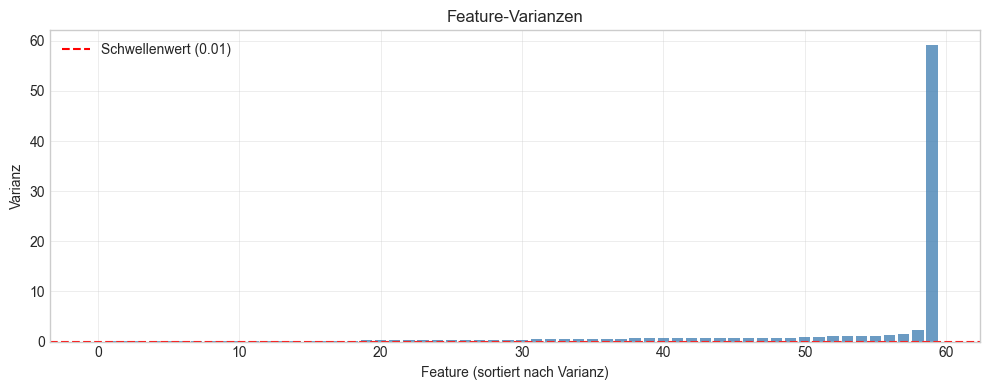

In [3]:
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
selector.fit(df)

variances = pd.Series(selector.variances_, index=df.columns).sort_values()
kept_variance = set(df.columns[selector.get_support()])
removed_variance = set(df.columns) - kept_variance

print(f"Schwellenwert: {VARIANCE_THRESHOLD}")
print(f"Entfernt: {len(removed_variance)} – {sorted(removed_variance)}")
print(f"Verbleibend: {len(kept_variance)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(variances)), variances.values, color="steelblue", alpha=0.8)
ax.axhline(VARIANCE_THRESHOLD, color="red", linestyle="--", label=f"Schwellenwert ({VARIANCE_THRESHOLD})")
ax.set_xlabel("Feature (sortiert nach Varianz)")
ax.set_ylabel("Varianz")
ax.set_title("Feature-Varianzen")
ax.legend()
plt.tight_layout()
plt.savefig("../documentation/figures/feature_selection/feature_varianz.png", dpi=150)
plt.show()

#### 4. Korrelations-Filter

Schwellenwert: |r| > 0.85
Entfernt: 1 – ['gender_Male']
Verbleibend: 58


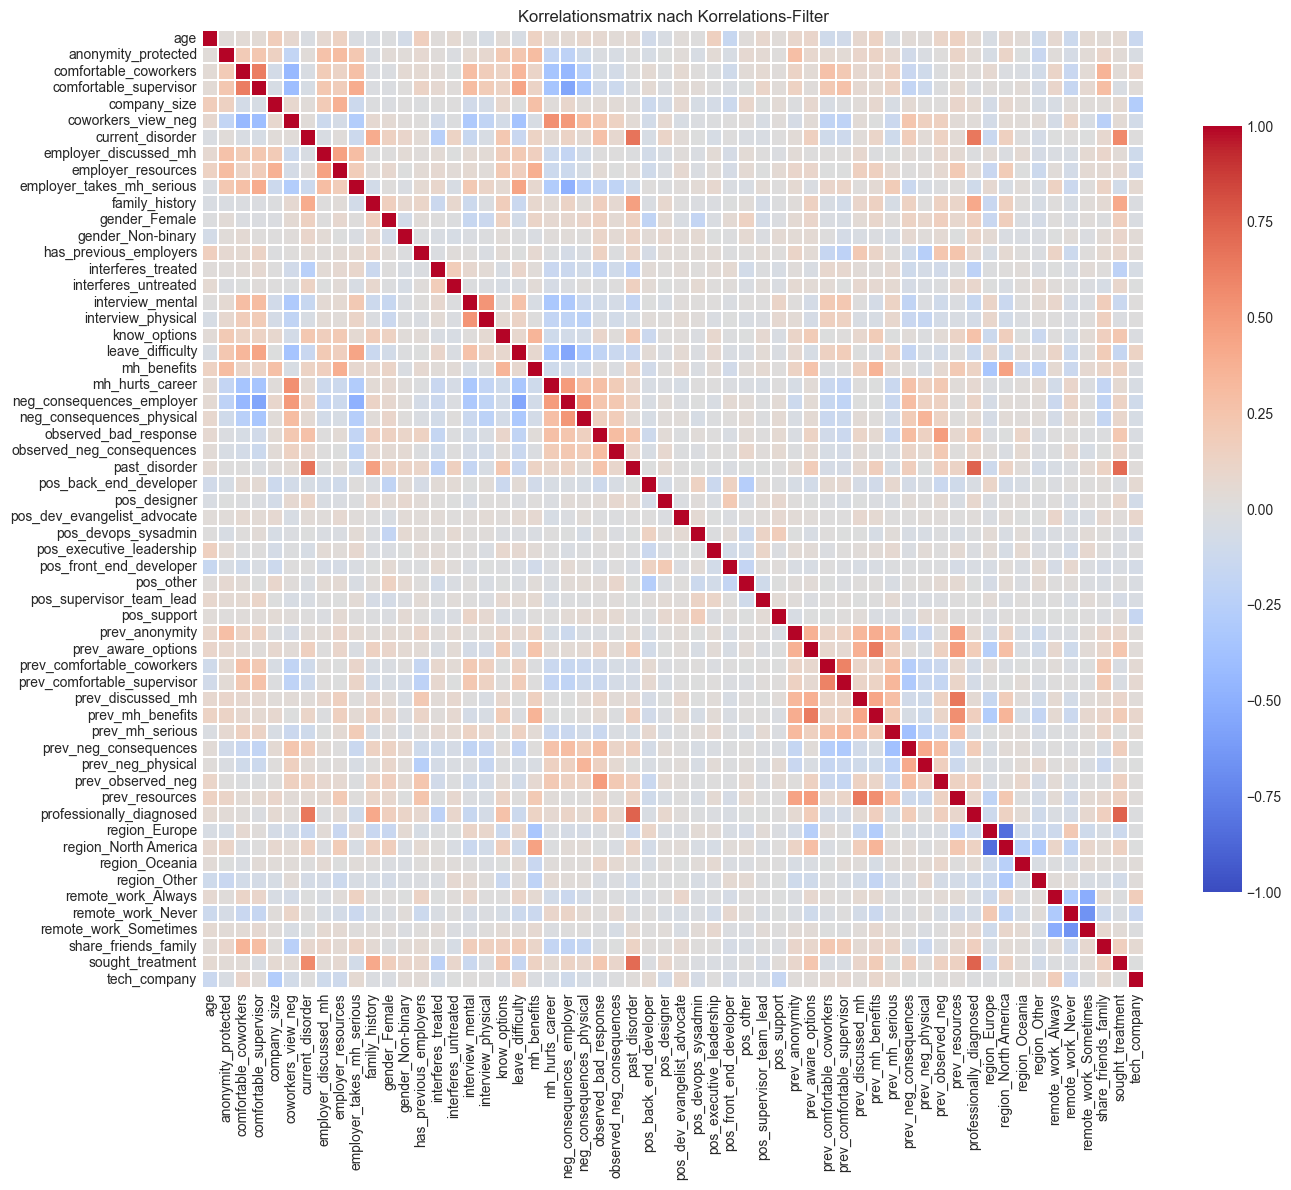

In [4]:
df_var = df[sorted(kept_variance)]
corr = df_var.corr(method="pearson").abs()

# Obere Dreiecksmatrix: je hochkorreliertes Paar das zweite Feature entfernen
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
removed_corr = set(col for col in upper.columns if (upper[col] > CORRELATION_THRESHOLD).any())
kept_corr = kept_variance - removed_corr

print(f"Schwellenwert: |r| > {CORRELATION_THRESHOLD}")
print(f"Entfernt: {len(removed_corr)} – {sorted(removed_corr)}")
print(f"Verbleibend: {len(kept_corr)}")

# Heatmap der verbleibenden Features
corr_kept = df[sorted(kept_corr)].corr(method="pearson")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_kept, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Korrelationsmatrix nach Korrelations-Filter")
plt.tight_layout()
plt.savefig("../documentation/figures/feature_selection/feature_korrelation.png", dpi=150)
plt.show()

#### 5. Mutual Information

professionally_diagnosed       0.307008
sought_treatment               0.286300
past_disorder                  0.252452
neg_consequences_employer      0.228863
prev_resources                 0.219857
current_disorder               0.211563
prev_discussed_mh              0.193664
prev_mh_benefits               0.192938
comfortable_supervisor         0.186267
comfortable_coworkers          0.175476
prev_aware_options             0.173753
mh_hurts_career                0.163912
coworkers_view_neg             0.154681
leave_difficulty               0.128266
share_friends_family           0.123433
prev_anonymity                 0.116846
prev_mh_serious                0.116646
interview_mental               0.113247
prev_neg_consequences          0.111261
family_history                 0.109484
region_North America           0.102655
observed_bad_response          0.095259
mh_benefits                    0.091086
neg_consequences_physical      0.086143
interview_physical             0.083178


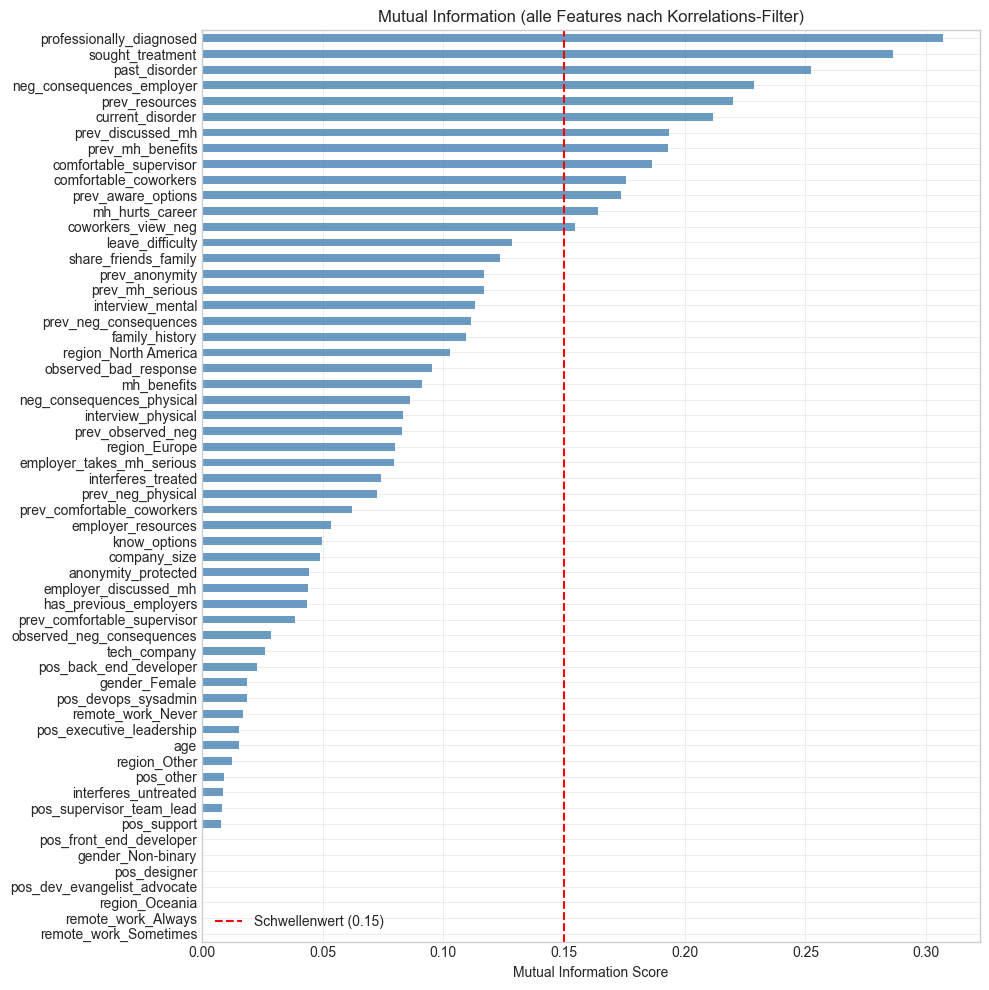

In [5]:
# Synthetische Labels via k-Means als Proxy für Cluster-Trennbarkeit
df_corr = df[sorted(kept_corr)]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_corr)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
pseudo_labels = kmeans.fit_predict(X_scaled)

mi_scores = mutual_info_classif(df_corr, pseudo_labels, random_state=42)
mi_series = pd.Series(mi_scores, index=df_corr.columns).sort_values(ascending=False)

kept_mi = set(mi_series[mi_series >= MI_THRESHOLD].index)
removed_mi = kept_corr - kept_mi

print(mi_series.to_string())

print(f"Schwellenwert: MI >= {MI_THRESHOLD}")
print(f"Entfernt: {len(removed_mi)} – {sorted(removed_mi)}")
print(f"Verbleibend: {len(kept_mi)}")

# Alle Features plotten, Schwellenwert markieren
fig, ax = plt.subplots(figsize=(10, 10))
mi_series.sort_values().plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
ax.axvline(MI_THRESHOLD, color="red", linestyle="--", label=f"Schwellenwert ({MI_THRESHOLD})")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Mutual Information (alle Features nach Korrelations-Filter)")
ax.legend()
plt.tight_layout()
plt.savefig("../documentation/figures/feature_selection/feature_mi.png", dpi=150)
plt.show()

#### 6. Finale Feature-Auswahl

In [6]:
final_features = sorted(kept_variance & kept_corr & kept_mi)

# Übersichtstabelle: Warum wurde jedes Feature entfernt?
all_features = list(df.columns)
records = []
for f in all_features:
    if f in removed_variance:
        reason = "Varianz-Filter"
    elif f in removed_corr:
        reason = "Korrelations-Filter"
    elif f in removed_mi:
        reason = "MI-Filter"
    else:
        reason = "behalten"
    records.append({"Feature": f, "Entscheidung": reason})

summary = pd.DataFrame(records)
print(summary.to_string(index=False))
print(f"\nFinale Feature-Anzahl: {len(final_features)}")

                    Feature        Entscheidung
               company_size           MI-Filter
               tech_company           MI-Filter
                mh_benefits           MI-Filter
               know_options           MI-Filter
      employer_discussed_mh           MI-Filter
         employer_resources           MI-Filter
        anonymity_protected           MI-Filter
           leave_difficulty           MI-Filter
  neg_consequences_employer            behalten
  neg_consequences_physical           MI-Filter
      comfortable_coworkers            behalten
     comfortable_supervisor            behalten
  employer_takes_mh_serious           MI-Filter
  observed_neg_consequences           MI-Filter
     has_previous_employers           MI-Filter
           prev_mh_benefits            behalten
         prev_aware_options            behalten
          prev_discussed_mh            behalten
             prev_resources            behalten
             prev_anonymity           MI

#### 7. Exportieren

In [7]:
df_selected = df[final_features]
df_selected.to_csv(OUTPUT_FILE, index=False)
print(f"Gespeichert: {OUTPUT_FILE}")
print(f"Shape: {df_selected.shape}")

Gespeichert: ../data/processed/selected_features.csv
Shape: (1142, 13)
